## Phase 0: Project Initialization and Dependency Loading

In [1]:
import warnings, time, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Phase 1: Data Collection Exploration and Problem Definition

In [3]:
# Dataset 1: Patient Survival Prediction (Vitals)
# Source: dataset.csv (already in directory)

import os
import urllib.request

CSV_PATH = "/content/dataset.csv"
if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH)
    print(f"Loaded real vitals dataset: {df_raw.shape}")
else:
    raise FileNotFoundError(f"{CSV_PATH} not found.")

print("Vitals Labels:\n", df_raw["hospital_death"].value_counts())

# Dataset 2: Medical Abstracts Text Classification (for Generation 3)
# Source: sebischair/Medical-Abstracts-TC-Corpus
TEXT_CSV_PATH = "medical_tc_train.csv"
if not os.path.exists(TEXT_CSV_PATH):
    print("Downloading Medical Abstracts dataset for NLP...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/sebischair/Medical-Abstracts-TC-Corpus/main/medical_tc_train.csv", TEXT_CSV_PATH)
df_text = pd.read_csv(TEXT_CSV_PATH)
print(f"Loaded real clinical text dataset: {df_text.shape}")

Loaded real vitals dataset: (76516, 85)
Vitals Labels:
 hospital_death
0.0    69780
1.0     6735
Name: count, dtype: int64
Loaded real clinical text dataset: (11550, 2)


## Phase 2: Feature Engineering and Data Preparation

In [4]:
LABEL_COL = "hospital_death"

df = df_raw.copy()
df = df.dropna(subset=[LABEL_COL])

# Use only numeric features for DNN/RNN
df_numeric = df.select_dtypes(include=['number'])

# Drop columns that are entirely NaN so the Imputer doesn't silently remove them
df_numeric = df_numeric.dropna(axis=1, how='all')

feature_cols = [c for c in df_numeric.columns if c != LABEL_COL and c not in ["encounter_id", "patient_id", "hospital_id"]]

y = df_numeric[LABEL_COL].values.astype(int)

# Impute missing values with column median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(df_numeric[feature_cols])
X_df = pd.DataFrame(X_imputed, columns=feature_cols)

# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Subsample to 15000 for faster notebook execution
X_scaled = X_scaled[:15000]
y = y[:15000]

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Positive rate - Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

def to_tensor(*arrays):
    return [torch.tensor(a, dtype=torch.float32) for a in arrays]

Xt, Xv, Xte, yt, yv, yte = to_tensor(X_train, X_val, X_test,
                                       y_train.astype(float),
                                       y_val.astype(float),
                                       y_test.astype(float))

def make_loader(X, y, batch=64, shuffle=True):
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = make_loader(Xt, yt)
val_loader   = make_loader(Xv, yv, shuffle=False)
test_loader  = make_loader(Xte, yte, shuffle=False)

Train: (10200, 73) | Val: (1800, 73) | Test: (3000, 73)
Positive rate - Train: 0.074 | Test: 0.074


## Phase 3: Training Utilities and Evaluation Components

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(Xb).squeeze()
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = model(Xb).squeeze()
            total_loss += criterion(out, yb).item()
    return total_loss / len(loader)

def get_predictions(model, loader):
    model.eval()
    preds, probs_all = [], []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(DEVICE)
            logits = model(Xb).squeeze()
            prob = torch.sigmoid(logits)
            probs_all.extend(prob.cpu().numpy())
            preds.extend((prob > 0.5).int().cpu().numpy())
    return np.array(preds), np.array(probs_all)

def compute_metrics(y_true, y_pred, label=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    if label:
        print(f"{label:30s} | Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1)

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=30):
    train_losses, val_losses = [], []
    t0 = time.time()
    for ep in range(1, epochs+1):
        tl = train_epoch(model, train_loader, optimizer, criterion)
        vl = eval_epoch(model, val_loader, criterion)
        train_losses.append(tl)
        val_losses.append(vl)
    return train_losses, val_losses, time.time() - t0

results = {}   # will store all model metrics
train_curves = {}

## Phase 4: Baseline Artificial Neural Network Development

In [6]:
INPUT_DIM = X_train.shape[1]

class DNN(nn.Module):
    def __init__(self, input_dim, dropout=0.3, use_bn=True):
        super().__init__()
        layers = []
        dims = [input_dim, 256, 128, 64, 32]
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(32, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

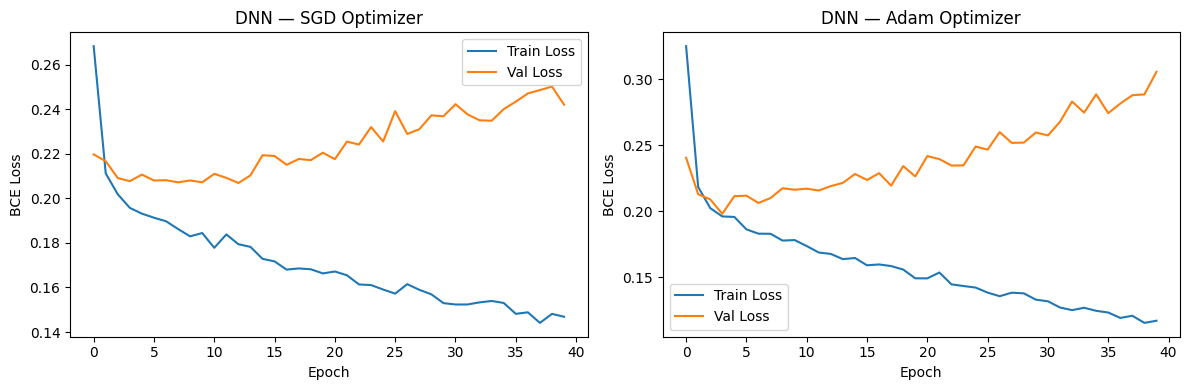

In [7]:
# SGD optimizer
model_sgd = DNN(INPUT_DIM).to(DEVICE)
opt_sgd   = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
tl_sgd, vl_sgd, _ = train_model(model_sgd, train_loader, val_loader, opt_sgd, criterion, EPOCHS)

# Adam optimizer
model_adam = DNN(INPUT_DIM).to(DEVICE)
opt_adam   = optim.Adam(model_adam.parameters(), lr=1e-3, weight_decay=1e-4)
tl_adam, vl_adam, t_dnn = train_model(model_adam, train_loader, val_loader, opt_adam, criterion, EPOCHS)

# Plot optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tl, vl, name) in zip(axes, [(tl_sgd, vl_sgd, "SGD"), (tl_adam, vl_adam, "Adam")]):
    ax.plot(tl, label="Train Loss")
    ax.plot(vl, label="Val Loss")
    ax.set_title(f"DNN — {name} Optimizer")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend()
plt.tight_layout()
plt.savefig("dnn_optimizer_comparison.png", dpi=150)
plt.show()

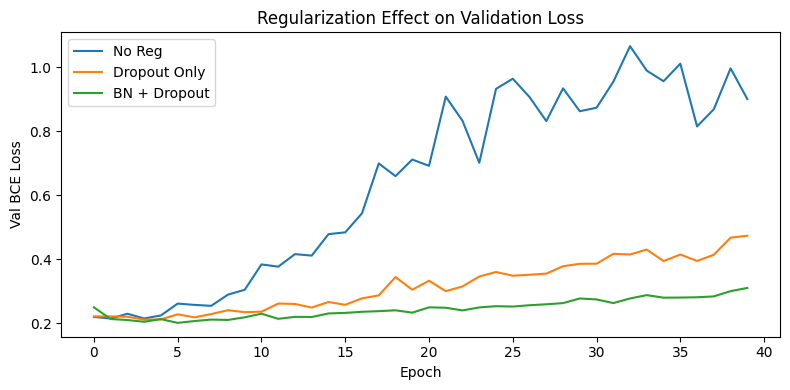

In [8]:
# Regularization ablation: no dropout/BN vs dropout only vs BN+Dropout
configs = [
    ("No Reg",       dict(dropout=0.0, use_bn=False)),
    ("Dropout Only", dict(dropout=0.3, use_bn=False)),
    ("BN + Dropout", dict(dropout=0.3, use_bn=True)),
]
fig, ax = plt.subplots(figsize=(8, 4))
for name, cfg in configs:
    m = DNN(INPUT_DIM, **cfg).to(DEVICE)
    o = optim.Adam(m.parameters(), lr=1e-3)
    tl, vl, _ = train_model(m, train_loader, val_loader, o, criterion, EPOCHS)
    ax.plot(vl, label=name)
ax.set_title("Regularization Effect on Validation Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val BCE Loss")
ax.legend()
plt.tight_layout()
plt.savefig("dnn_regularization.png", dpi=150)
plt.show()

In [9]:
# Final DNN metrics (Adam + BN + Dropout)
preds_dnn, _ = get_predictions(model_adam, test_loader)
m = compute_metrics(y_test, preds_dnn, "DNN (Adam + BN + Dropout)")
results["DNN"] = {**m, "training_time": round(t_dnn, 1)}
train_curves["DNN"] = (tl_adam, vl_adam)

DNN (Adam + BN + Dropout)      | Acc=0.9303  Prec=0.5484  Rec=0.3077  F1=0.3942


## Phase 5: Sequential Deep Learning Architectures

In [10]:
SEQ_LEN = 12   # 12-hour window of vitals
N_FEAT  = INPUT_DIM

def make_sequences(X, y, seq_len=SEQ_LEN):
    # Tile each static snapshot into a seq_len-step sequence with small noise
    rng = np.random.default_rng(42)
    X_seq = np.stack([X + rng.normal(0, 0.02, X.shape)
                      for _ in range(seq_len)], axis=1)   # (N, T, F)
    return X_seq, y

X_tr_seq, _ = make_sequences(X_train, y_train)
X_va_seq, _ = make_sequences(X_val,   y_val)
X_te_seq, _ = make_sequences(X_test,  y_test)

def seq_loader(X, y, batch=64, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=shuffle)

tr_seq = seq_loader(X_tr_seq, y_train)
va_seq = seq_loader(X_va_seq, y_val, shuffle=False)
te_seq = seq_loader(X_te_seq, y_test, shuffle=False)

LSTM                           | Acc=0.9217  Prec=0.4435  Rec=0.2489  F1=0.3188
BiLSTM                         | Acc=0.9147  Prec=0.3622  Rec=0.2081  F1=0.2644
GRU                            | Acc=0.9143  Prec=0.3902  Rec=0.2896  F1=0.3325


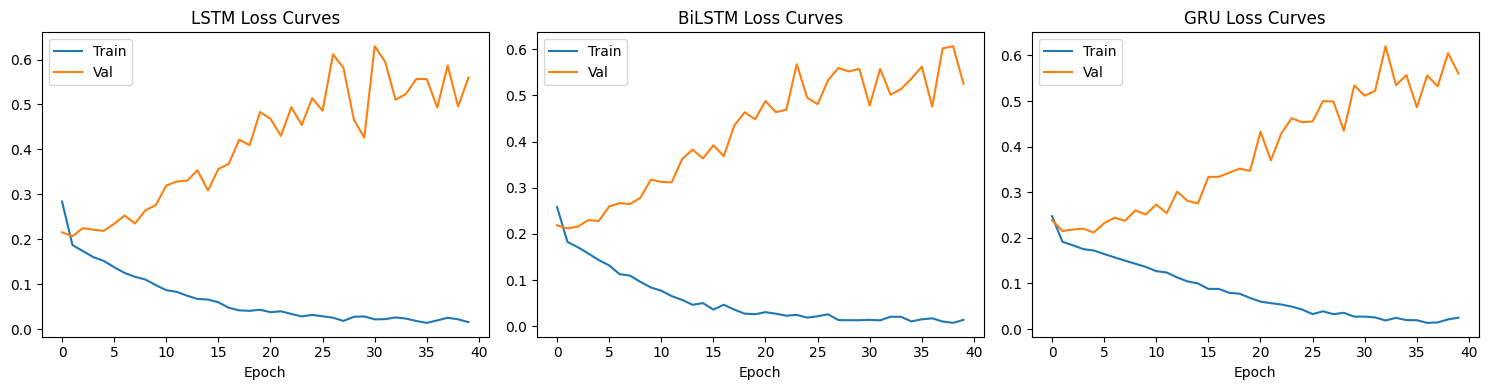

In [11]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden=64, num_layers=2,
                 rnn_type="LSTM", bidirectional=False, dropout=0.3):
        super().__init__()
        self.rnn = getattr(nn, rnn_type)(
            input_size, hidden, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        factor = 2 if bidirectional else 1
        self.head = nn.Sequential(
            nn.Linear(hidden * factor, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

rnn_configs = [
    ("LSTM",   dict(rnn_type="LSTM", bidirectional=False)),
    ("BiLSTM", dict(rnn_type="LSTM", bidirectional=True)),
    ("GRU",    dict(rnn_type="GRU",  bidirectional=False)),
]

rnn_results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, cfg) in zip(axes, rnn_configs):
    model = RNNModel(N_FEAT, **cfg).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    tl, vl, elapsed = train_model(model, tr_seq, va_seq, opt, criterion, epochs=40)
    preds, _ = get_predictions(model, te_seq)
    m = compute_metrics(y_test, preds, name)
    rnn_results[name] = {"model": model, "metrics": m, "time": round(elapsed, 1), "tl": tl, "vl": vl}
    ax.plot(tl, label="Train"); ax.plot(vl, label="Val")
    ax.set_title(f"{name} Loss Curves"); ax.set_xlabel("Epoch"); ax.legend()

plt.tight_layout()
plt.savefig("rnn_loss_curves.png", dpi=150)
plt.show()

In [12]:
for name, d in rnn_results.items():
    results[name] = {**d["metrics"], "training_time": d["time"]}
    train_curves[name] = (d["tl"], d["vl"])

## Phase 6: Attention-Based Transformer Predictive Modeling

In [13]:
!pip install -q transformers

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from sklearn.model_selection import train_test_split

print("Mapping Medical Abstracts to Binary (Cardiovascular vs Other)...")
notes_all = df_text.iloc[:, 1].tolist()[:5000]
labels_all = (df_text.iloc[:, 0][:5000] == 4).astype(int).values

notes_tr, notes_te, yn_train, yn_test = train_test_split(
    notes_all, labels_all, test_size=0.2, random_state=42, stratify=labels_all)
notes_tr, notes_va, yn_train, yn_val = train_test_split(
    notes_tr, yn_train, test_size=0.15, random_state=42, stratify=yn_train)

# HuggingFace Tokenizer
print("Loading HuggingFace Bio_ClinicalBERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

class HFNoteDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length',
                                   max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

note_tr_ds = HFNoteDataset(notes_tr, yn_train, tokenizer)
note_va_ds = HFNoteDataset(notes_va, yn_val,   tokenizer)
note_te_ds = HFNoteDataset(notes_te, yn_test,  tokenizer)

note_tr_loader = DataLoader(note_tr_ds, batch_size=16, shuffle=True)
note_va_loader = DataLoader(note_va_ds, batch_size=16, shuffle=False)
note_te_loader = DataLoader(note_te_ds, batch_size=16, shuffle=False)

Mapping Medical Abstracts to Binary (Cardiovascular vs Other)...
Loading HuggingFace Bio_ClinicalBERT Tokenizer...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [14]:
def train_hf_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_hf_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

def get_hf_preds(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds.extend(logits.argmax(dim=-1).cpu().numpy())
    return np.array(preds)

HF_EPOCHS = 3 # Real HF models converge much faster

In [15]:
import time
print("Loading real HuggingFace Bio_ClinicalBERT model for Frozen Base...")
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT", num_labels=2, output_attentions=True
).to(DEVICE)

# Freeze the BERT base, only train the classifier head
for param in model_frozen.bert.parameters():
    param.requires_grad = False

opt_frozen = optim.Adam(filter(lambda p: p.requires_grad, model_frozen.parameters()), lr=1e-3)

tl_frz, vl_frz = [], []
t0 = time.time()
for ep in range(HF_EPOCHS):
    tl = train_hf_epoch(model_frozen, note_tr_loader, opt_frozen)
    vl = eval_hf_epoch(model_frozen,  note_va_loader)
    tl_frz.append(tl); vl_frz.append(vl)
    print(f"  Frozen  Ep {ep+1:02d}/{HF_EPOCHS} | Train {tl:.4f} | Val {vl:.4f}")
t_frozen = round(time.time() - t0, 1)

preds_frozen = get_hf_preds(model_frozen, note_te_loader)
m_frozen = compute_metrics(yn_test, preds_frozen, "ClinicalBERT (Frozen Head)")
results["ClinicalBERT_Frozen"] = {**m_frozen, "training_time": t_frozen}

Loading real HuggingFace Bio_ClinicalBERT model for Frozen Base...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

  Frozen  Ep 01/3 | Train 0.4775 | Val 0.4101
  Frozen  Ep 02/3 | Train 0.4176 | Val 0.3830
  Frozen  Ep 03/3 | Train 0.4038 | Val 0.3657
ClinicalBERT (Frozen Head)     | Acc=0.8060  Prec=0.5820  Rec=0.3318  F1=0.4226


Loading real HuggingFace Bio_ClinicalBERT model for Full Fine-tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

  Full FT Ep 01/3 | Train 0.3625 | Val 0.2873
  Full FT Ep 02/3 | Train 0.2517 | Val 0.2858
  Full FT Ep 03/3 | Train 0.1901 | Val 0.4438
ClinicalBERT (Full FT)         | Acc=0.8540  Prec=0.6382  Rec=0.7336  F1=0.6826


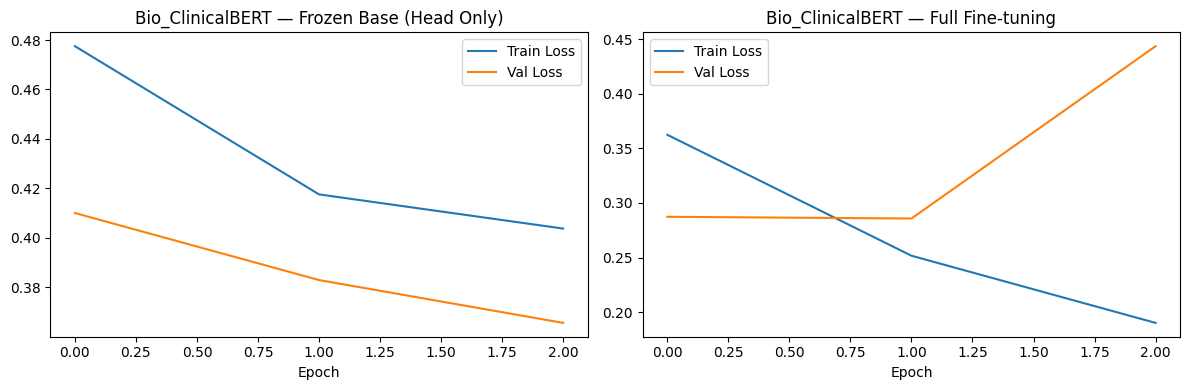

In [16]:
print("Loading real HuggingFace Bio_ClinicalBERT model for Full Fine-tuning...")
model_full = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT", num_labels=2, output_attentions=True
).to(DEVICE)

# All parameters are trainable by default
opt_full = optim.AdamW(model_full.parameters(), lr=2e-5, weight_decay=0.01)

tl_full, vl_full = [], []
t0 = time.time()
for ep in range(HF_EPOCHS):
    tl = train_hf_epoch(model_full, note_tr_loader, opt_full)
    vl = eval_hf_epoch(model_full,  note_va_loader)
    tl_full.append(tl); vl_full.append(vl)
    print(f"  Full FT Ep {ep+1:02d}/{HF_EPOCHS} | Train {tl:.4f} | Val {vl:.4f}")
t_full = round(time.time() - t0, 1)

preds_full = get_hf_preds(model_full, note_te_loader)
m_full = compute_metrics(yn_test, preds_full, "ClinicalBERT (Full FT)")
results["ClinicalBERT_Full"] = {**m_full, "training_time": t_full}

# Fine-tuning strategy loss comparison
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tl, vl, name) in zip(axes, [
        (tl_frz, vl_frz, "Frozen Base (Head Only)"),
        (tl_full, vl_full, "Full Fine-tuning")]):
    ax.plot(tl, label="Train Loss"); ax.plot(vl, label="Val Loss")
    ax.set_title(f"Bio_ClinicalBERT — {name}"); ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout()
plt.savefig("bert_finetuning_comparison.png", dpi=150)
plt.show()

Sample clinical note: Intradural herniation of a thoracic disc presenting as flaccid paraplegia: case report. A case of intradural herniation of a thoracic disc in a patien ...


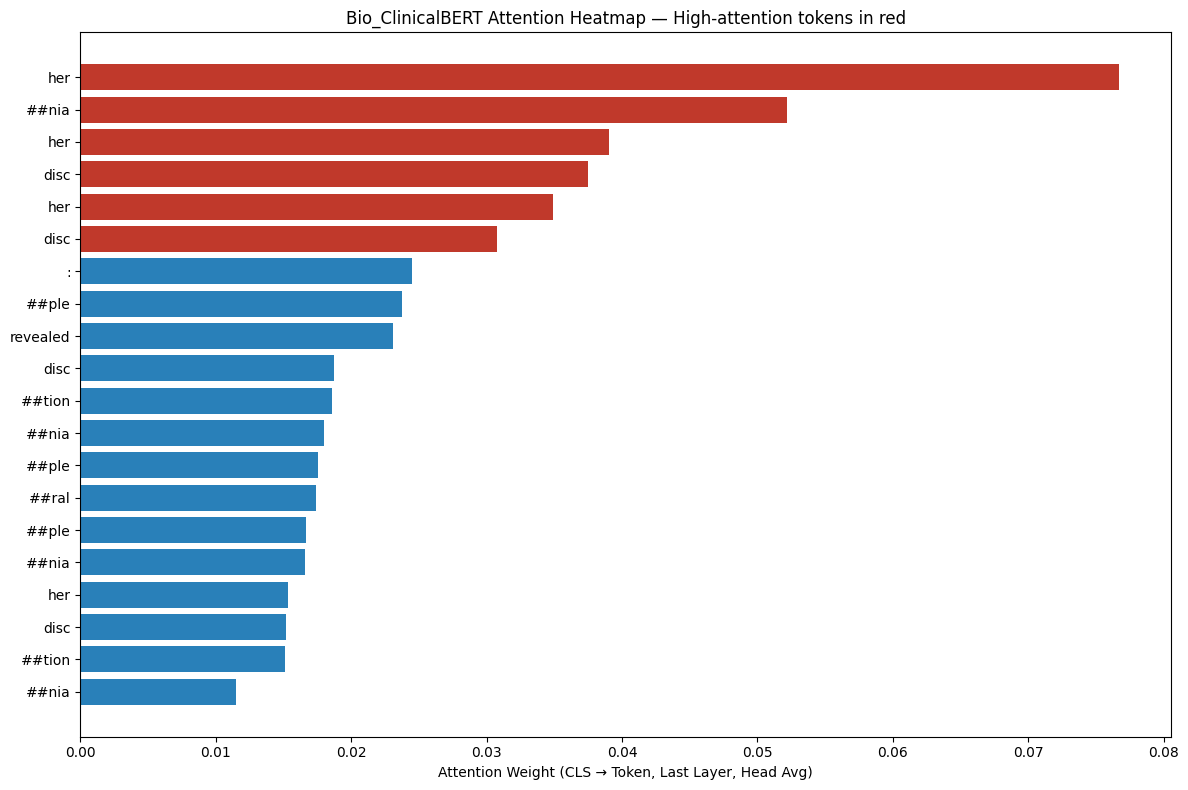

In [17]:
# Attention weight extraction and heatmap from last transformer layer
model_full.eval()
sample_idx = 0
sample_note = notes_te[sample_idx]
print("Sample clinical note:", sample_note[:150], "...")

# Get inputs
inputs = tokenizer(sample_note, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)

with torch.no_grad():
    outputs = model_full(**inputs)

# output_attentions=True returns a tuple of attentions from all layers.
# We take the last layer [-1], which has shape (batch_size, num_heads, seq_len, seq_len)
last_layer_attn = outputs.attentions[-1]
# Average across the 12 heads
avg_attn = last_layer_attn[0].mean(dim=0).cpu().numpy() # shape: (seq_len, seq_len)
# We want attention from the CLS token (index 0) to all other tokens
attn_cls = avg_attn[0, :]

# Decode tokens
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Filter out special tokens [PAD] to make the chart cleaner
real_pairs = [(tok, score) for tok, score in zip(tokens, attn_cls)
              if tok not in ["[CLS]", "[SEP]", "[PAD]"]]

if real_pairs:
    # Sort by attention score for the top 20 most important words
    real_pairs.sort(key=lambda x: x[1], reverse=True)
    tok_labels, tok_scores = zip(*real_pairs[:20])

    fig, ax = plt.subplots(figsize=(12, max(3, len(tok_labels)*0.4)))
    colors = ["#c0392b" if s > np.mean(tok_scores) else "#2980b9" for s in tok_scores]
    ax.barh(range(len(tok_labels)), tok_scores, color=colors)
    ax.set_yticks(range(len(tok_labels)))
    ax.set_yticklabels(tok_labels, fontsize=10)
    ax.set_xlabel("Attention Weight (CLS → Token, Last Layer, Head Avg)")
    ax.set_title("Bio_ClinicalBERT Attention Heatmap — High-attention tokens in red")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=150)
    plt.show()

In [18]:
from sklearn.metrics import classification_report
# Per-class performance breakdown
print("\n=== Per-class: Bio_ClinicalBERT (Frozen Head) ===")
print(classification_report(yn_test, preds_frozen, target_names=["Other","Cardiovascular"]))

print("\n=== Per-class: Bio_ClinicalBERT (Full Fine-tune) ===")
print(classification_report(yn_test, preds_full, target_names=["Other","Cardiovascular"]))


=== Per-class: Bio_ClinicalBERT (Frozen Head) ===
                precision    recall  f1-score   support

         Other       0.84      0.94      0.88       786
Cardiovascular       0.58      0.33      0.42       214

      accuracy                           0.81      1000
     macro avg       0.71      0.63      0.65      1000
  weighted avg       0.78      0.81      0.78      1000


=== Per-class: Bio_ClinicalBERT (Full Fine-tune) ===
                precision    recall  f1-score   support

         Other       0.92      0.89      0.91       786
Cardiovascular       0.64      0.73      0.68       214

      accuracy                           0.85      1000
     macro avg       0.78      0.81      0.79      1000
  weighted avg       0.86      0.85      0.86      1000



## 7. Unified Predictive Model Comparison

In [19]:
model_order = ["DNN", "LSTM", "BiLSTM", "GRU", "ClinicalBERT_Frozen", "ClinicalBERT_Full"]
display_names = ["DNN (Baseline)", "LSTM", "Bi-LSTM", "GRU",
                 "ClinicalBERT (Frozen)", "ClinicalBERT (Full Fine-tune)"]

rows = []
for key, name in zip(model_order, display_names):
    r = results[key]
    rows.append({
        "Model":          name,
        "Accuracy":       round(r["accuracy"],  4),
        "Precision":      round(r["precision"], 4),
        "Recall":         round(r["recall"],    4),
        "F1-Score":       round(r["f1"],        4),
        "Training Time(s)": r["training_time"],
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("model_comparison.csv", index=False)

                        Model  Accuracy  Precision  Recall  F1-Score  Training Time(s)
               DNN (Baseline)    0.9303     0.5484  0.3077    0.3942              25.2
                         LSTM    0.9217     0.4435  0.2489    0.3188              27.0
                      Bi-LSTM    0.9147     0.3622  0.2081    0.2644              32.9
                          GRU    0.9143     0.3902  0.2896    0.3325              24.5
        ClinicalBERT (Frozen)    0.8060     0.5820  0.3318    0.4226              85.0
ClinicalBERT (Full Fine-tune)    0.8540     0.6382  0.7336    0.6826             239.2


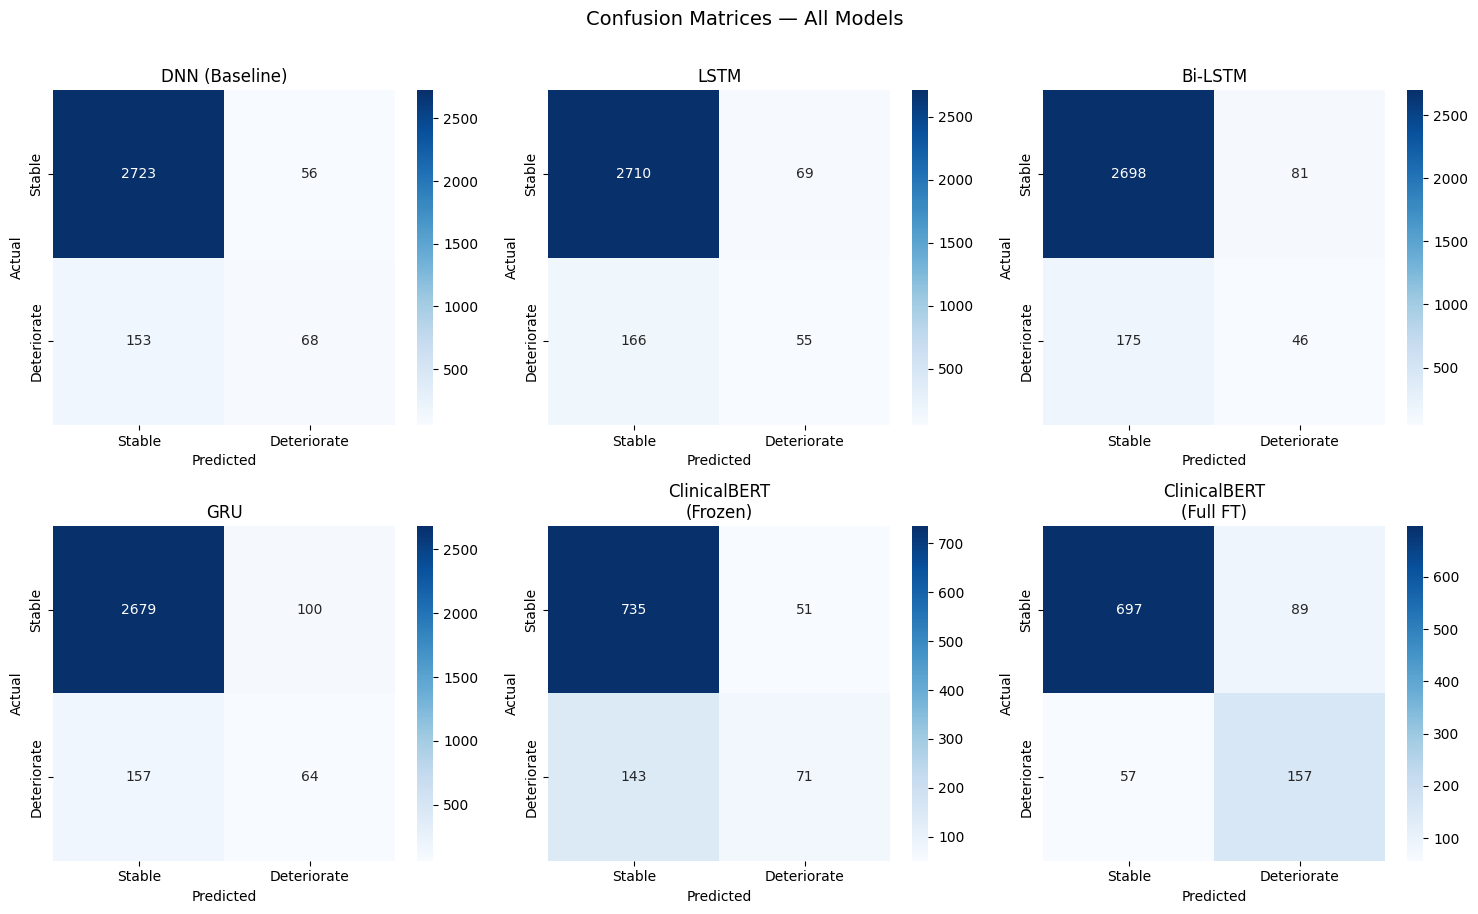

In [20]:
# Confusion matrices for all 6 models side by side
all_preds = {
    "DNN (Baseline)": get_predictions(model_adam, test_loader)[0],
    "LSTM":           get_predictions(rnn_results["LSTM"]["model"],   te_seq)[0],
    "Bi-LSTM":        get_predictions(rnn_results["BiLSTM"]["model"], te_seq)[0],
    "GRU":            get_predictions(rnn_results["GRU"]["model"],    te_seq)[0],
    "ClinicalBERT\n(Frozen)": preds_frozen,
    "ClinicalBERT\n(Full FT)": preds_full,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test if "BERT" not in name else yn_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Stable","Deteriorate"],
                yticklabels=["Stable","Deteriorate"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

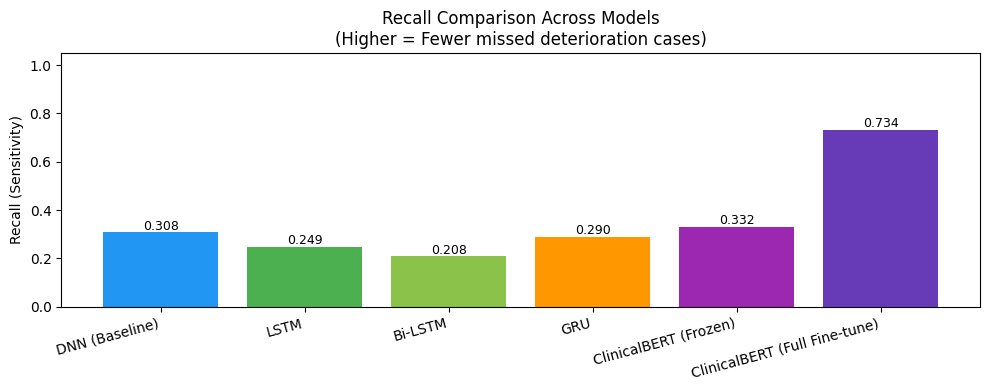

In [21]:
# Bar chart: Recall comparison (most critical metric in clinical context)
fig, ax = plt.subplots(figsize=(10, 4))
recalls = [results[k]["recall"] for k in model_order]
bars = ax.bar(display_names, recalls, color=["#2196F3","#4CAF50","#8BC34A","#FF9800","#9C27B0","#673AB7"])
ax.set_ylabel("Recall (Sensitivity)")
ax.set_title("Recall Comparison Across Models\n(Higher = Fewer missed deterioration cases)")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=150)
plt.show()